In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [2]:
df = pd.read_csv("diabetes_prediction_dataset.csv")

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
print(df.shape)

df.info()

(100000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [4]:
print("Missing Values\n")

print(df.isnull().sum())

Missing Values

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

print(df.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [6]:
print("Duplicate Rows :", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("After Removal :", df.shape)

Duplicate Rows : 3854
After Removal : (96146, 9)


In [7]:
Q1 = df["blood_glucose_level"].quantile(0.25)
Q3 = df["blood_glucose_level"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["blood_glucose_level"] < lower) |
    (df["blood_glucose_level"] > upper)
]

print(outliers.head())

     gender   age  hypertension  heart_disease smoking_history    bmi  \
38     Male  50.0             1              0         current  27.32   
94   Female  60.0             0              0           never  27.32   
104  Female  80.0             1              0           never  27.32   
125  Female  77.0             0              0           never  31.70   
142  Female  80.0             0              0          former  21.97   

     HbA1c_level  blood_glucose_level  diabetes  
38           5.7                  260         1  
94           7.5                  300         1  
104          6.8                  280         1  
125          6.5                  280         1  
142          7.0                  300         1  


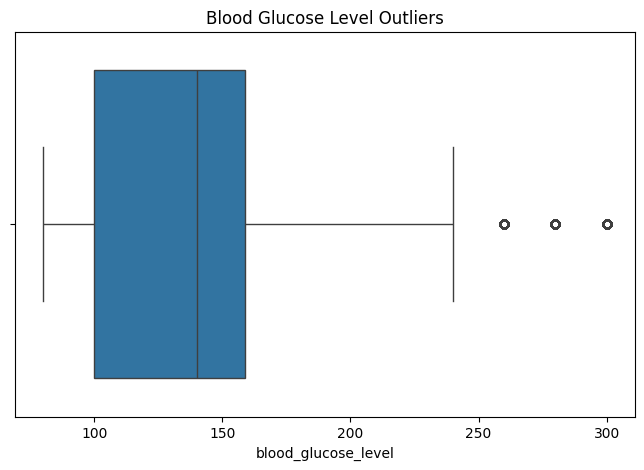

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["blood_glucose_level"])

plt.title("Blood Glucose Level Outliers")

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [10]:
numeric_cols = [
    "age",
    "hypertension",
    "heart_disease",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

scaler = MinMaxScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print(df[numeric_cols].head())

        age  hypertension  heart_disease       bmi  HbA1c_level  \
0  1.000000           0.0            1.0  0.177171     0.563636   
1  0.674675           0.0            0.0  0.202031     0.563636   
2  0.349349           0.0            0.0  0.202031     0.400000   
3  0.449449           0.0            0.0  0.156863     0.272727   
4  0.949950           1.0            1.0  0.118231     0.236364   

   blood_glucose_level  
0             0.272727  
1             0.000000  
2             0.354545  
3             0.340909  
4             0.340909  


In [11]:
encoder = LabelEncoder()

df["gender"] = encoder.fit_transform(df["gender"])

print(df[["gender"]].head())

   gender
0       0
1       0
2       1
3       0
4       1


In [12]:
encoder = LabelEncoder()

df["smoking_history"] = encoder.fit_transform(
    df["smoking_history"]
)

print(df[["smoking_history"]].head())

   smoking_history
0                4
1                0
2                4
3                1
4                1


In [13]:
encoder = LabelEncoder()

df["diabetes"] = encoder.fit_transform(df["diabetes"])

print(df[["diabetes"]].head())

   diabetes
0         0
1         0
2         0
3         0
4         0


In [14]:
print(df.shape)

df.info()

(96146, 9)
<class 'pandas.core.frame.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  int64  
 1   age                  96146 non-null  float64
 2   hypertension         96146 non-null  float64
 3   heart_disease        96146 non-null  float64
 4   smoking_history      96146 non-null  int64  
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  float64
 8   diabetes             96146 non-null  int64  
dtypes: float64(6), int64(3)
memory usage: 7.3 MB


In [15]:
df.to_csv(
    "cleaned_diabetes_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
